### Descripcion del dataset

- `01dataBaseTrainTrxRec.csv` - dataset de entrenamiento a nivel de transacciones.
- `02dataBasePerfilRec.csv` - dataset del perfil de cliente.
- `03dataBaseTestRec.csv` - dataset de prueba para base a nivel de clientes-establecimientos.
- `04diccionarioRec.csv` - descripción de variables.
- `05dataBaseTestKeyRec.csv` - dataset adicional en caso lo requiera, donde está desagregado el campo [codClienteCodEstab] en "codCliente" y "codEstab", igual la solución la deben enviar en el archivo "03dataBaseTestRec.csv" tal como se describió anteriormente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('01dataBaseTrainTrxRec.csv')
perfil = pd.read_csv('02dataBasePerfilRec.csv')
test_key = pd.read_csv('05dataBaseTestKeyRec.csv')

# Dimensiones
print("TRAIN:", train.shape)
print("PERFIL:", perfil.shape)
print("TEST:", test_key.shape)

# Tipos de datos y nulos
print(train.info())
print(train.describe())

TRAIN: (1591617, 8)
PERFIL: (30000, 14)
TEST: (467203, 2)
<class 'pandas.DataFrame'>
RangeIndex: 1591617 entries, 0 to 1591616
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   fechaOper          1591617 non-null  str    
 1   codCliente         1591617 non-null  int64  
 2   codGiro            1498931 non-null  float64
 3   codEstab           1591617 non-null  int64  
 4   flagLimaProvEstab  1591617 non-null  int64  
 5   ubigeoEstab        1498931 non-null  float64
 6   ctdTrx             1591617 non-null  int64  
 7   ratingMonto        1591617 non-null  float64
dtypes: float64(3), int64(4), str(1)
memory usage: 97.1 MB
None
         codCliente       codGiro      codEstab  flagLimaProvEstab  \
count  1.591617e+06  1.498931e+06  1.591617e+06       1.591617e+06   
mean   1.334583e+04  1.048248e+02  2.453260e+04       8.084175e-01   
std    8.493548e+03  3.920585e+01  1.990371e+04       3.935464e-01 

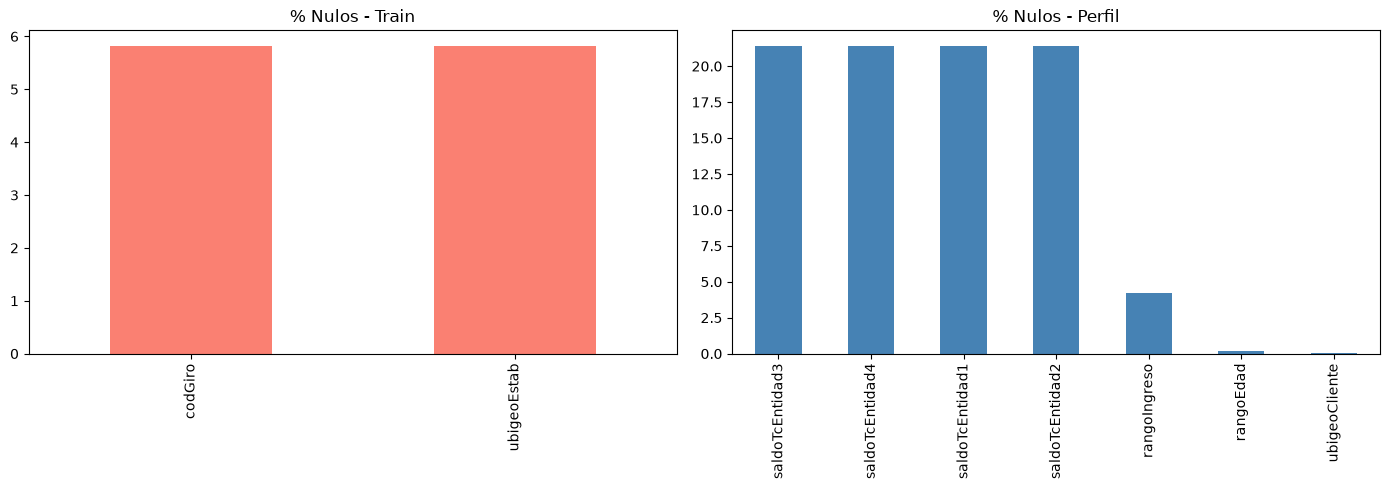

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
nulls_train = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
nulls_train[nulls_train > 0].plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('% Nulos - Train')

# Perfil
nulls_perfil = (perfil.isnull().sum() / len(perfil) * 100).sort_values(ascending=False)
nulls_perfil[nulls_perfil > 0].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('% Nulos - Perfil')

plt.tight_layout()
plt.show()

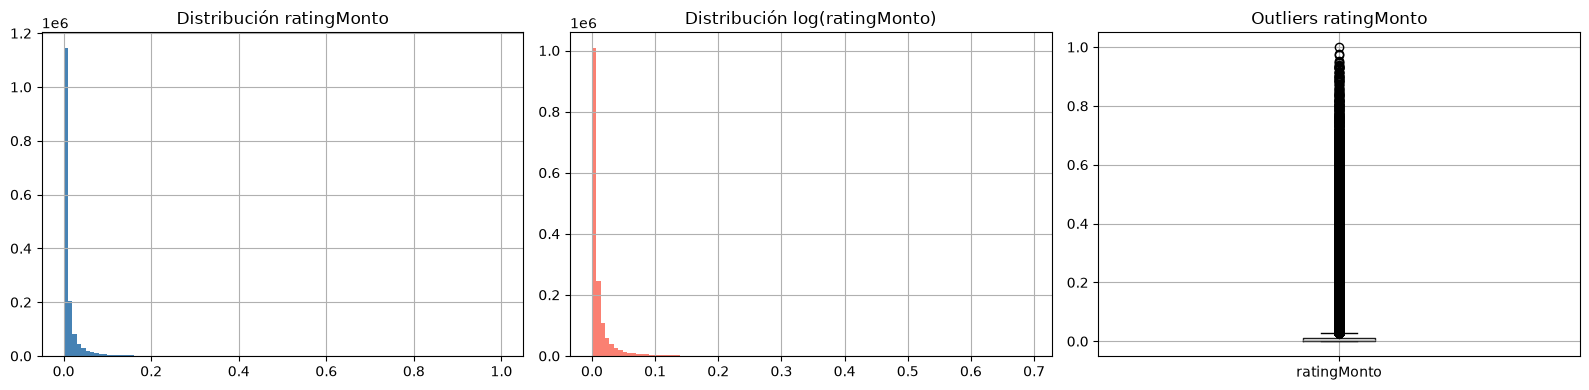

count    1.591617e+06
mean     1.318383e-02
std      3.236438e-02
min      2.984905e-06
25%      1.598366e-03
50%      4.199563e-03
75%      1.152572e-02
max      1.000000e+00
Name: ratingMonto, dtype: float64
Valores > 1: 0
Valores = 0: 0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución general
train['ratingMonto'].hist(bins=100, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución ratingMonto')

# Distribución en escala log (suele ser muy skewed)
np.log1p(train['ratingMonto']).hist(bins=100, ax=axes[1], color='salmon')
axes[1].set_title('Distribución log(ratingMonto)')

# Boxplot para ver outliers
train.boxplot(column='ratingMonto', ax=axes[2])
axes[2].set_title('Outliers ratingMonto')

plt.tight_layout()
plt.show()

print(train['ratingMonto'].describe())
print(f"Valores > 1: {(train['ratingMonto'] > 1).sum()}")
print(f"Valores = 0: {(train['ratingMonto'] == 0).sum()}")

count    30000.000000
mean        30.065567
std         30.462245
min          1.000000
25%         10.000000
50%         20.000000
75%         39.000000
max        276.000000
Name: codEstab, dtype: float64


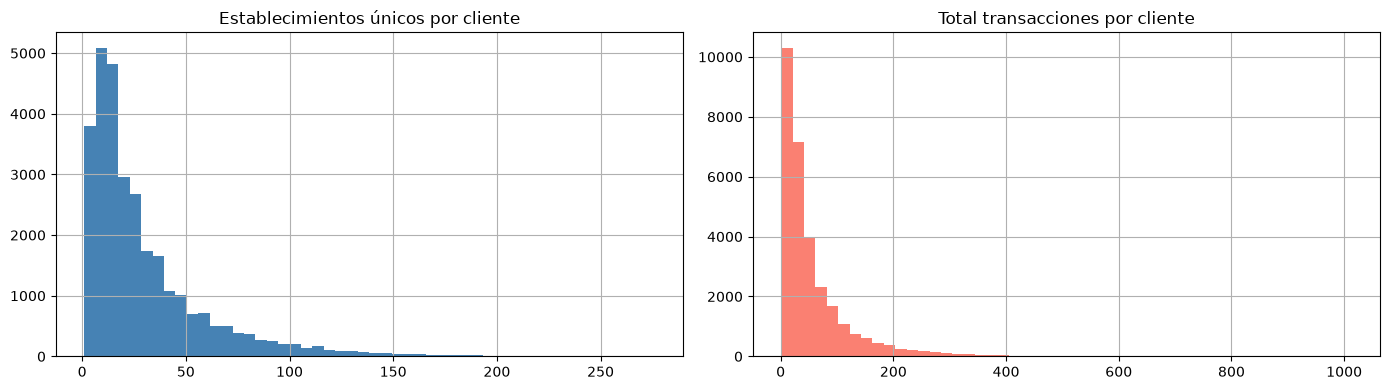

In [4]:
# ¿Cuántos establecimientos visita cada cliente?
estab_por_cliente = train.groupby('codCliente')['codEstab'].nunique()
print(estab_por_cliente.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

estab_por_cliente.hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Establecimientos únicos por cliente')

# ¿Cuántas transacciones por cliente?
trx_por_cliente = train.groupby('codCliente')['ctdTrx'].sum()
trx_por_cliente.hist(bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Total transacciones por cliente')

plt.tight_layout()
plt.show()

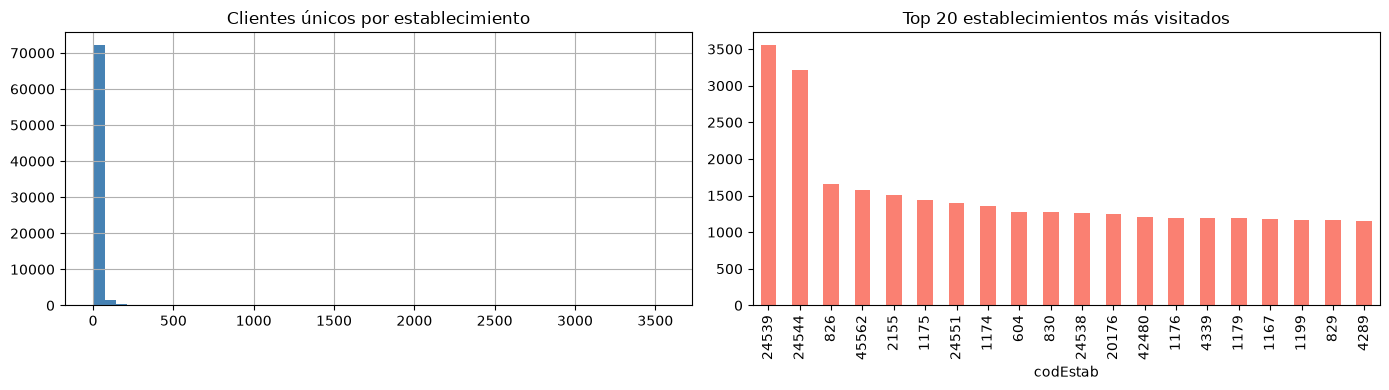

In [5]:
# ¿Cuántos clientes tiene cada establecimiento? (popularidad)
clientes_por_estab = train.groupby('codEstab')['codCliente'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clientes_por_estab.hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Clientes únicos por establecimiento')

# Top 20 establecimientos más populares
clientes_por_estab.head(20).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Top 20 establecimientos más visitados')

plt.tight_layout()
plt.show()

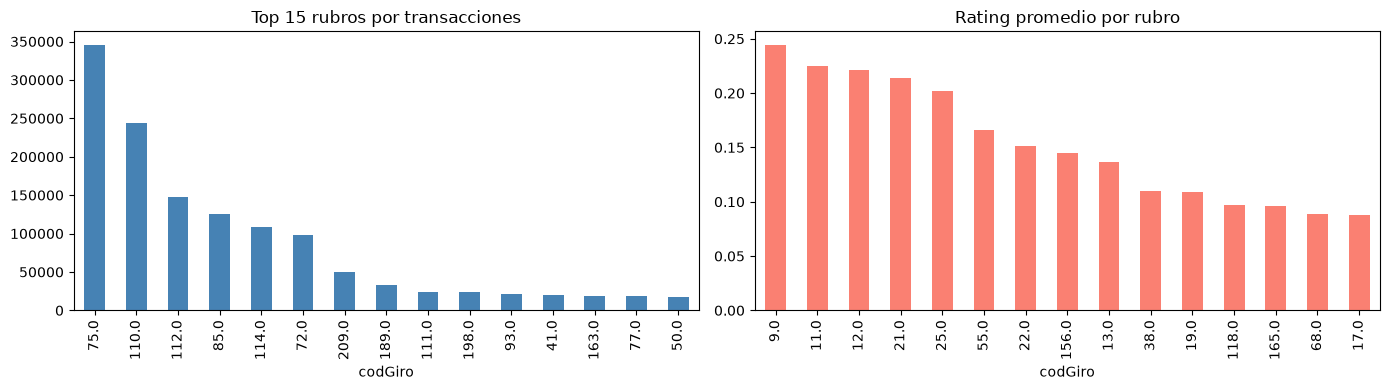

In [6]:
# ¿Qué rubros concentran más transacciones?
giro_trx = train.groupby('codGiro')['ctdTrx'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

giro_trx.head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 rubros por transacciones')

# Rating promedio por giro
giro_rating = train.groupby('codGiro')['ratingMonto'].mean().sort_values(ascending=False)
giro_rating.head(15).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Rating promedio por rubro')

plt.tight_layout()
plt.show()

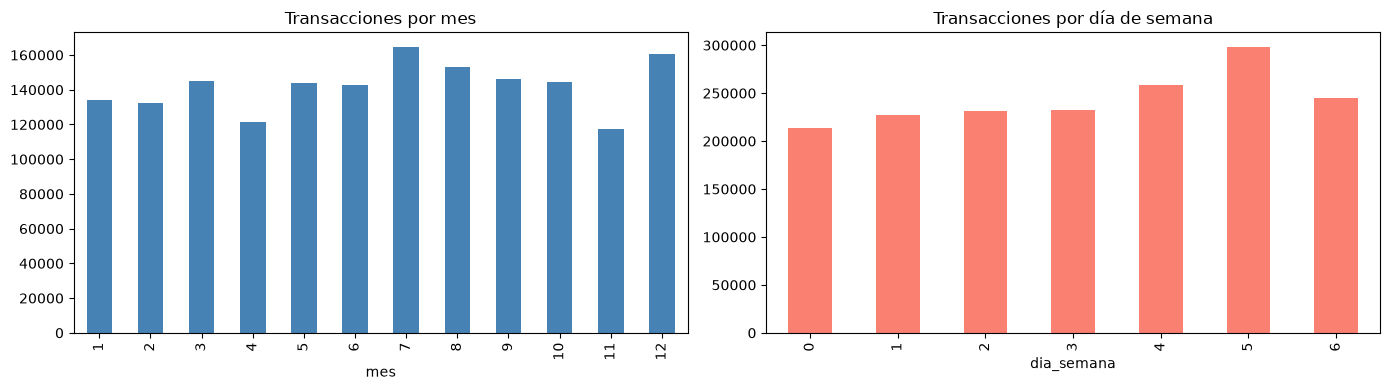

In [7]:
train['fechaOper'] = pd.to_datetime(train['fechaOper'])
train['mes'] = train['fechaOper'].dt.month
train['dia_semana'] = train['fechaOper'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Transacciones por mes
train.groupby('mes')['ctdTrx'].sum().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transacciones por mes')

# Transacciones por día de semana
train.groupby('dia_semana')['ctdTrx'].sum().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Transacciones por día de semana')

plt.tight_layout()
plt.show()

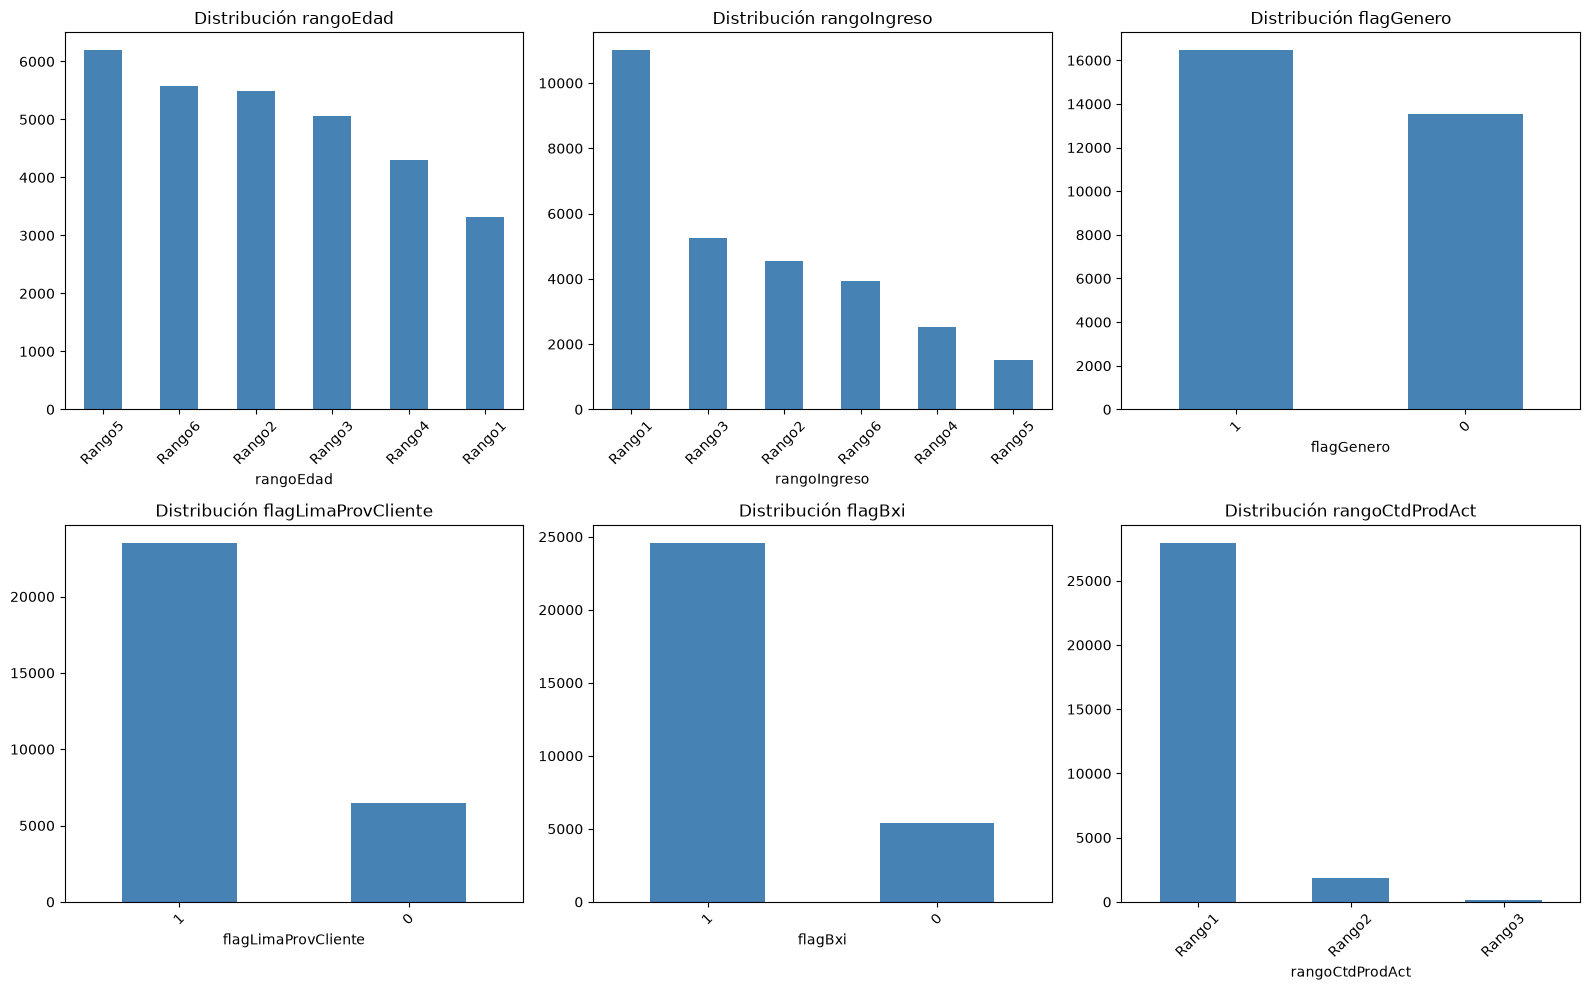

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cols = ['rangoEdad', 'rangoIngreso', 'flagGenero',
        'flagLimaProvCliente', 'flagBxi', 'rangoCtdProdAct']

for ax, col in zip(axes.flatten(), cols):
    perfil[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Distribución {col}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

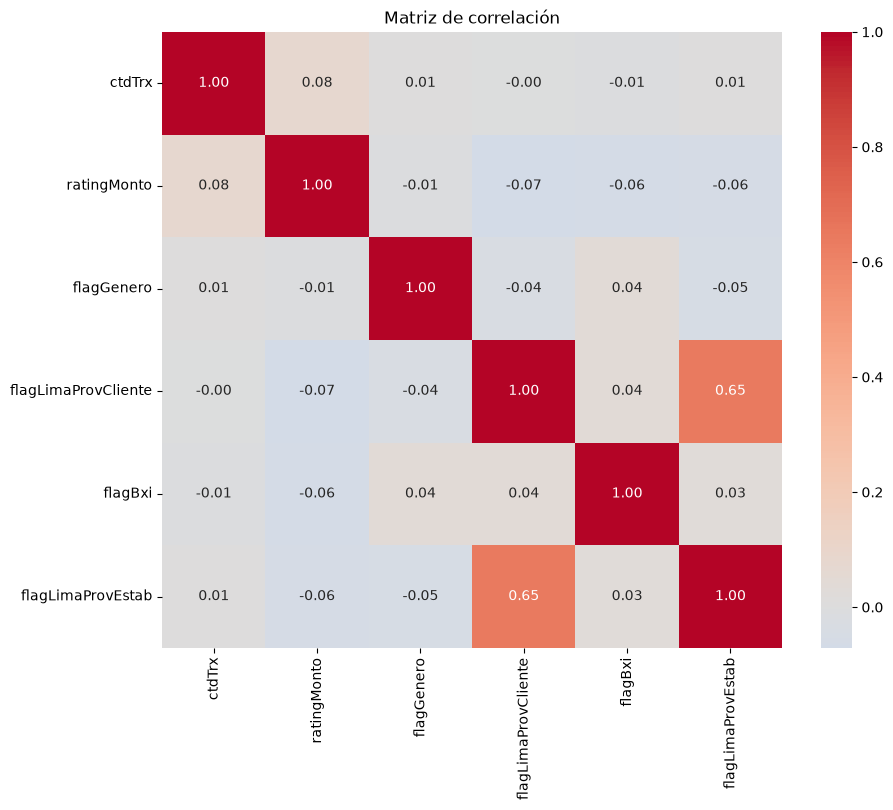

In [9]:
train_merged = train.merge(perfil, on='codCliente', how='left')

num_cols = ['ctdTrx', 'ratingMonto', 'flagGenero',
            'flagLimaProvCliente', 'flagBxi',
            'flagLimaProvEstab']

plt.figure(figsize=(10, 8))
sns.heatmap(train_merged[num_cols].corr(),
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

In [10]:
clientes_train = set(train['codCliente'].unique())
estab_train = set(train['codEstab'].unique())
clientes_test = set(test_key['codCliente'].unique())
estab_test = set(test_key['codEstab'].unique())

print(f"Clientes en test sin historial: {len(clientes_test - clientes_train)} "
      f"({(len(clientes_test - clientes_train)/len(clientes_test)*100):.1f}%)")
print(f"Establecimientos en test sin historial: {len(estab_test - estab_train)} "
      f"({(len(estab_test - estab_train)/len(estab_train)*100):.1f}%)")

Clientes en test sin historial: 0 (0.0%)
Establecimientos en test sin historial: 7939 (10.7%)
